In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import mne
from mne import Epochs, find_events, make_ad_hoc_cov
from mne.datasets import sample
from mne.simulation import simulate_raw, simulate_sparse_stc, add_ecg, add_eog, add_noise
from mne.viz import plot_sparse_source_estimates

In [72]:
class utils:

    @staticmethod
    def evoked(times):
        t_peak = 0.15
        return (
            50e-9
            * np.sin(30.0 * times)
            * np.exp(-((times - t_peak + 0.05 * np.random.randn(1)) ** 2) / 0.01)
        )


## Preparation: Computing the Forward Model

Load raw data as template

In [ ]:
raw_fname = mne.datasets.eegbci.load_data(subjects=1, runs=[6])[0]
raw = mne.io.read_raw_edf(raw_fname, preload=True)
montage = mne.channels.make_standard_montage("standard_1005")
mne.datasets.eegbci.standardize(raw)
raw.set_montage(montage);

Load the forward model (this takes a while)

In [ ]:
fs_dir = mne.datasets.fetch_fsaverage(verbose=True)
src = fs_dir / "bem" / "fsaverage-ico-5-src.fif"
bem = fs_dir / "bem" / "fsaverage-5120-5120-5120-bem-sol.fif"

Plot the source locations together with the EEG sensors.

In [ ]:
mne.viz.plot_alignment(
    raw.info,
    src=src,
    eeg=["original", "projected"],
    trans="fsaverage",
)

## Selecting and Visualizing Vertices in the Brain

Read labels for left and right cortex

In [ ]:
labels = mne.read_labels_from_annot('fsaverage', parc='aparc', subjects_dir=fs_dir.parent)
labels

In [ ]:
label_name = "entorhinal-lh"
label = [l for l in labels if l.name == label_name][0]
label

brain = mne.viz.Brain('fsaverage', hemi='both', subjects_dir=fs_dir.parent, surf='pial')
brain.add_label(label, color='blue', alpha=0.7)

In [ ]:
label_name = "insula-rh"
label = [l for l in labels if l.name == label_name][0]
label

brain = mne.viz.Brain('fsaverage', hemi='both', subjects_dir=fs_dir.parent, surf='pial')
brain.add_label(label, color='blue', alpha=0.7)

In [ ]:
label_name = "transversetemporal-lh"
label = [l for l in labels if l.name == label_name][0]
label

brain = mne.viz.Brain('fsaverage', hemi='both', subjects_dir=fs_dir.parent, surf='pial')
brain.add_label(label, color='blue', alpha=0.7)

Highlight vertex at [0, 0, 0].

In [ ]:
brain = mne.viz.Brain('fsaverage', hemi='both', subjects_dir=fs_dir.parent, surf='pial', alpha=0.5)
brain.add_foci([0.0, 0.0, 0.0], hemi='lh', color='yellow', scale_factor=0.5)


## Simulating Source Activty

In [ ]:
fwd = mne.make_forward_solution(
    raw.info, trans="fsaverage", src=src, bem=bem, eeg=True, mindist=5.0, n_jobs=None
)
fwd

In [ ]:
times = np.arange(0, 1, 1/raw.info["sfreq"])

In [ ]:
stc = simulate_sparse_stc(
    fwd["src"],
    n_dipoles=2,
    times=times,
)
stc.plot(hemi="both")

In [ ]:
stc = simulate_sparse_stc(
    fwd["src"],
    n_dipoles=20,
    times=times,
)
stc.plot(hemi="both")

Plot source activity

In [81]:
raw.info["dev_head_t"] = fwd["info"]["dev_head_t"]

In [85]:
n_epochs = 100
raw_sim = simulate_raw(raw.info, [stc] * n_epochs, forward=fwd, verbose=False)

In [89]:
n_samples_per_epoch = len(stc.times)
events = np.array([
    [i * n_samples_per_epoch, 0, 1] 
    for i in range(n_epochs)
])

Not setting metadata
100 matching events found
No baseline correction applied
0 projection items activated
No projector specified for this dataset. Please consider the method self.add_proj.


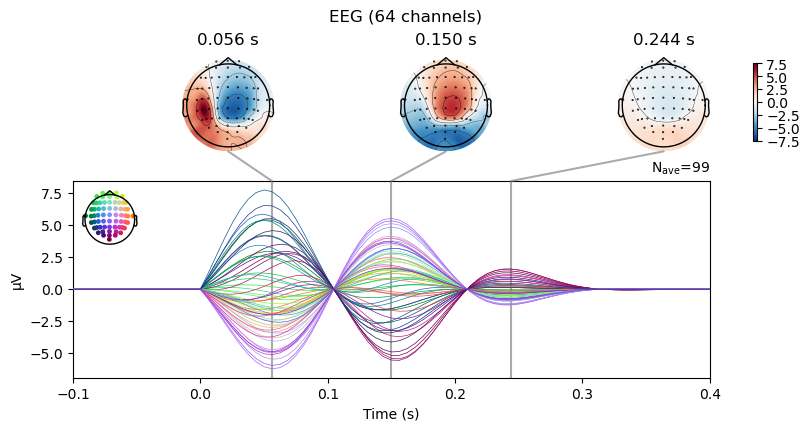

In [92]:
epochs = Epochs(raw_sim, events, tmin=-0.1, tmax=0.4, baseline=None)
epochs.average().plot_joint();

Add noise

In [ ]:
cov = make_ad_hoc_cov(raw_sim.info)
add_noise(raw_sim, cov, iir_filter=[0.2, -0.2, 0.04], random_state=rng)
add_eog(raw_sim, random_state=rng)
raw_sim.plot()

In [ ]:
raw.compute_psd().plot();

In [ ]:

events = find_events(raw_sim)
epochs = Epochs(raw_sim, events, tmin=-0.1, tmax=0.4, baseline=None)
epochs.average().plot_joint();